In [1]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from TMFG_core import TMFG

/Users/simone/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
df_nmi = pd.read_csv("../csv_NMI_matrix/lob_similarity_nmi_rellag_lag150_bins2000_mean.csv")

In [5]:
df_nmi

,Unnamed: 0,ask_0_lag_0,ask_0_lag_1,ask_0_lag_2,ask_0_lag_3,ask_0_lag_4,ask_0_lag_5,ask_0_lag_6,ask_0_lag_7,ask_0_lag_8,...,bid_9_lag_141,bid_9_lag_142,bid_9_lag_143,bid_9_lag_144,bid_9_lag_145,bid_9_lag_146,bid_9_lag_147,bid_9_lag_148,bid_9_lag_149,bid_9_lag_150
0,ask_0_lag_0,1.000000,0.756847,0.667598,0.605596,0.565680,0.531609,0.506608,0.483594,0.465564,...,0.198426,0.198415,0.198388,0.198393,0.198333,0.198280,0.198360,0.198393,0.198458,0.198440
1,ask_0_lag_1,0.756847,1.000000,0.756847,0.667598,0.605596,0.565680,0.531609,0.506608,0.483594,...,0.198503,0.198426,0.198415,0.198388,0.198393,0.198333,0.198280,0.198360,0.198393,0.198458
2,ask_0_lag_2,0.667598,0.756847,1.000000,0.756847,0.667598,0.605596,0.565680,0.531609,0.506608,...,0.198578,0.198503,0.198426,0.198415,0.198388,0.198393,0.198333,0.198280,0.198360,0.198393
3,ask_0_lag_3,0.605596,0.667598,0.756847,1.000000,0.756847,0.667598,0.605596,0.565680,0.531609,...,0.198692,0.198578,0.198503,0.198426,0.198415,0.198388,0.198393,0.198333,0.198280,0.198360
4,ask_0_lag_4,0.565680,0.605596,0.667598,0.756847,1.000000,0.756847,0.667598,0.605596,0.565680,...,0.198789,0.198692,0.198578,0.198503,0.198426,0.198415,0.198388,0.198393,0.198333,0.198280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3015,bid_9_lag_146,0.198280,0.198333,0.198393,0.198388,0.198415,0.198426,0.198503,0.198578,0.198692,...,0.925528,0.937368,0.950138,0.964117,0.979908,1.000000,0.979908,0.964117,0.950138,0.937368
3016,bid_9_lag_147,0.198360,0.198280,0.198333,0.198393,0.198388,0.198415,0.198426,0.198503,0.198578,...,0.914461,0.925528,0.937368,0.950138,0.964117,0.979908,1.000000,0.979908,0.964117,0.950138
3017,bid_9_lag_148,0.198393,0.198360,0.198280,0.198333,0.198393,0.198388,0.198415,0.198426,0.198503,...,0.904091,0.914461,0.925528,0.937368,0.950138,0.964117,0.979908,1.000000,0.979908,0.964117
3018,bid_9_lag_149,0.198458,0.198393,0.198360,0.198280,0.198333,0.198393,0.198388,0.198415,0.198426,...,0.894335,0.904091,0.914461,0.925528,0.937368,0.950138,0.964117,0.979908,1.000000,0.979908


In [6]:
df_nmi.describe()

,ask_0_lag_0,ask_0_lag_1,ask_0_lag_2,ask_0_lag_3,ask_0_lag_4,ask_0_lag_5,ask_0_lag_6,ask_0_lag_7,ask_0_lag_8,ask_0_lag_9,...,bid_9_lag_141,bid_9_lag_142,bid_9_lag_143,bid_9_lag_144,bid_9_lag_145,bid_9_lag_146,bid_9_lag_147,bid_9_lag_148,bid_9_lag_149,bid_9_lag_150
count,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,...,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000
mean,0.246649,0.246863,0.247046,0.247210,0.247359,0.247498,0.247629,0.247752,0.247868,0.247979,...,0.412720,0.412384,0.412039,0.411685,0.411321,0.410946,0.410560,0.410161,0.409749,0.409321
std,0.037825,0.038950,0.039697,0.040231,0.040647,0.040976,0.041247,0.041471,0.041660,0.041821,...,0.101829,0.101444,0.101039,0.100613,0.100164,0.099688,0.099184,0.098649,0.098077,0.097464
min,0.188087,0.188087,0.188087,0.188087,0.188087,0.188087,0.188087,0.188087,0.188087,0.188087,...,0.195647,0.195647,0.195624,0.195566,0.195516,0.195516,0.195516,0.195516,0.195481,0.195418
25%,0.217667,0.217671,0.217688,0.217794,0.217960,0.218170,0.218294,0.218326,0.218528,0.218638,...,0.391746,0.391612,0.391499,0.391390,0.391257,0.391090,0.390953,0.390836,0.390744,0.390668
50%,0.249178,0.249242,0.249277,0.249307,0.249332,0.249385,0.249490,0.249560,0.249591,0.249649,...,0.432075,0.432024,0.431968,0.431877,0.431744,0.431674,0.431509,0.431292,0.431139,0.430955
75%,0.265688,0.265709,0.265795,0.265831,0.265937,0.265971,0.266058,0.266169,0.266358,0.266501,...,0.449319,0.449029,0.448763,0.448543,0.448155,0.447856,0.447536,0.447213,0.446854,0.446545
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
df_nmi_fixed = df_nmi.set_index('Unnamed: 0')

In [8]:
cols_lag0 = [c for c in df_nmi.columns if 'lag_0' in str(c)]

df_filtered = df_nmi_fixed.copy()

is_lag0_col = df_nmi_fixed.columns.isin(cols_lag0)
is_lag0_row = df_nmi_fixed.index.astype(str).str.contains('lag_0')

mask = np.outer(is_lag0_row, np.ones(len(is_lag0_col), dtype=bool)) | \
       np.outer(np.ones(len(is_lag0_row), dtype=bool), is_lag0_col)
df_filtered.values[~mask] = 0


In [9]:
df_filtered.describe()

,ask_0_lag_0,ask_0_lag_1,ask_0_lag_2,ask_0_lag_3,ask_0_lag_4,ask_0_lag_5,ask_0_lag_6,ask_0_lag_7,ask_0_lag_8,ask_0_lag_9,...,bid_9_lag_141,bid_9_lag_142,bid_9_lag_143,bid_9_lag_144,bid_9_lag_145,bid_9_lag_146,bid_9_lag_147,bid_9_lag_148,bid_9_lag_149,bid_9_lag_150
count,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,...,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000,3020.000000
mean,0.246649,0.001817,0.001787,0.001767,0.001753,0.001743,0.001734,0.001727,0.001721,0.001716,...,0.002595,0.002594,0.002593,0.002592,0.002591,0.002590,0.002590,0.002589,0.002589,0.002588
std,0.037825,0.024130,0.023243,0.022677,0.022328,0.022057,0.021863,0.021696,0.021561,0.021450,...,0.032386,0.032377,0.032365,0.032353,0.032340,0.032329,0.032323,0.032313,0.032303,0.032293
min,0.188087,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.217667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.249178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.265688,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,0.756847,0.667598,0.605596,0.565680,0.531609,0.506608,0.483594,0.465564,0.448765,...,0.511803,0.510839,0.509900,0.508930,0.507946,0.507037,0.506199,0.505321,0.504467,0.503599


In [10]:
tmfg = TMFG()
tmfg.fit(weights=df_filtered, output='unweighted_sparse_W_matrix')
cliques, separators, adj_matrix = tmfg.transform()

In [11]:
df_adj = pd.DataFrame(adj_matrix, index=df_filtered.columns, columns=df_filtered.columns)

# 2. Salva in CSV (facile da condividere e leggero)
df_adj.to_csv('tmfg_adj_matrix_250_bins.csv')

In [12]:
# Creazione del grafo NetworkX
G = nx.from_pandas_adjacency(pd.DataFrame(adj_matrix, index=df_filtered.index, columns=df_filtered.columns))

# Analisi del grafo

1. Market Influence (Redundancy-Filtered Hubs)

Unique Connection Leadership: Nonostante l'annullamento delle similarità ridondanti tra i lag, ask_1 e bid_1 restano i leader. Questo prova che la loro centralità non è un artefatto dovuto alla ripetizione temporale, ma una dominanza strutturale reale.

Effective Bridges: I nodi con alta Betweenness (ask_6, bid_4) agiscono come "canali di sbarramento": sono gli unici punti rimasti che collegano blocchi informativi diversi dopo che la ridondanza è stata eliminata.

Focus on Lag 0: La rete finale premia il tempo reale (lag_0), indicando che le relazioni cross-sectional sono più forti di qualsiasi legame predittivo residuo sopravvissuto al filtraggio.

2. Clique Composition (Temporal Chains)

Anti-Redundancy Effect: Il fatto che le clique abbiano solo 2 variabili diverse è il risultato diretto della tua regola. Eliminando le similarità tra lag (es. sim(A 
lag2
​	
 ,B 
lag1
​	
 )), hai costretto il sistema a collassare su catene verticali o coppie fisse.

Persistent Core: Il nucleo (bid_4 to bid_7) è la parte della matrice che ha resistito meglio alla rimozione della ridondanza. Rappresenta lo scheletro informativo più "originale" e meno ripetitivo dell'Order Book.

Structural Sparsity: La quasi totale assenza di clique con 3 o 4 variabili diverse conferma che, tolta la ridondanza, il mercato non è un blocco unico ma un insieme di processi a coppie altamente indipendenti.

3. Network Efficiency (Filtered Small-World)

Optimized Skeleton: Il TMFG ha costruito un grafo planare di 9.054 archi usando solo informazioni "nuove", avendo scartato quelle ridondanti. È una mappa dell'efficienza informativa pura.

High Local Cohesion: Il coefficiente di 0.83 dimostra che le variabili raggruppate (nonostante il taglio dei lag ridondanti) formano cluster estremamente solidi.

Small-World Robustness: Una distanza media di 5.65 in una rete così filtrata indica che il sistema Order Book è intrinsecamente connesso: anche eliminando i doppioni temporali, ogni nodo resta raggiungibile in pochissimi passaggi.

Top 10 Variabili più influenti (Hub):
             Degree Centrality  Betweenness
bid_4_lag_0           0.277244     0.262270
bid_3_lag_0           0.248427     0.234956
ask_4_lag_0           0.182842     0.428115
ask_3_lag_0           0.172242     0.119519
bid_5_lag_0           0.164624     0.320625
bid_6_lag_0           0.117920     0.100606
ask_5_lag_0           0.110301     0.186575
ask_6_lag_0           0.101689     0.153440
ask_8_lag_0           0.101027     0.067967
ask_7_lag_0           0.100696     0.091925
bid_7_lag_0           0.099702     0.078798
bid_8_lag_0           0.051010     0.041451
ask_9_lag_0           0.051010     0.043136
bid_9_lag_0           0.051010     0.009916
bid_2_lag_0           0.051010     0.006904
ask_2_lag_0           0.051010     0.031674
ask_1_lag_0           0.033455     0.009986
bid_1_lag_0           0.030474     0.000436
bid_0_lag_0           0.013581     0.000080
ask_0_lag_0           0.013249     0.000076


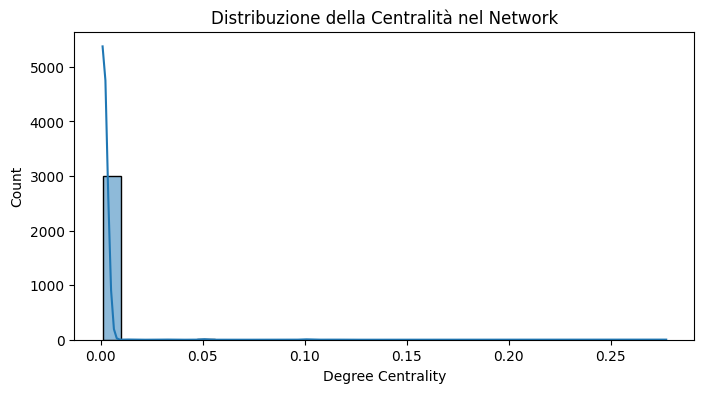

In [13]:
# Calcolo metriche
degree_cent = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G)

# Creazione DataFrame per confronto
df_stats = pd.DataFrame({
    'Degree Centrality': pd.Series(degree_cent),
    'Betweenness': pd.Series(betweenness)
}).sort_values(by='Degree Centrality', ascending=False)

print("Top 10 Variabili più influenti (Hub):")
print(df_stats.head(20))

# Visualizzazione distribuzione gradi
plt.figure(figsize=(8, 4))
sns.histplot(df_stats['Degree Centrality'], bins=30, kde=True)
plt.title("Distribuzione della Centralità nel Network")
plt.show()

Nucleo del sistema (First 4-clique): ['bid_4_lag_0', 'ask_4_lag_0', 'bid_5_lag_0', 'bid_3_lag_0']


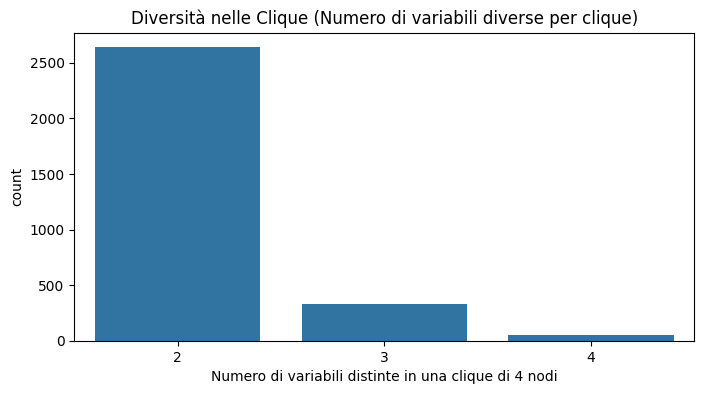

In [14]:
# Analisi della prima clique (il nucleo del sistema)
core_nodes = [df_nmi_fixed.columns[i] for i in cliques[0]]
print(f"Nucleo del sistema (First 4-clique): {core_nodes}")

# Studio della composizione delle clique
def analyze_clique_composition(clique_indices):
    nodes = [df_nmi_fixed.columns[i] for i in clique_indices]
    base_names = [n.split('_lag')[0] for n in nodes]
    return len(set(base_names))

clique_diversity = [analyze_clique_composition(c) for c in cliques]
plt.figure(figsize=(8, 4))
sns.countplot(x=clique_diversity)
plt.title("Diversità nelle Clique (Numero di variabili diverse per clique)")
plt.xlabel("Numero di variabili distinte in una clique di 4 nodi")
plt.show()

In [15]:
import networkx as nx
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# --- 1. VERIFICA DELLA COERENZA TOPOLOGICA ---

n_nodi = len(G.nodes)
n_archi_attesi = 3 * n_nodi - 6
n_archi_reali = len(G.edges)

print(f"--- Validazione Topologica ---")
print(f"Nodi: {n_nodi} | Archi reali: {n_archi_reali} | Attesi: {n_archi_attesi}")
if n_archi_reali == n_archi_attesi:
    print("Stato: OK. Il grafo rispetta il vincolo di planarità TMFG.")

# --- 2. IDENTIFICAZIONE DEI "PONTI" (Bridges) ---

sep_flat = [node_idx for s in separators for node_idx in s]
sep_counts = Counter(sep_flat)

# Convertiamo gli indici in nomi di variabili
ponti_nomi = {df_nmi_fixed.columns[idx]: count for idx, count in sep_counts.items()}
df_ponti = pd.Series(ponti_nomi).sort_values(ascending=False)

print(f"\n--- Top 10 Nodi 'Ponte' (Frequenza nei Separatori) ---")
print(df_ponti.head(10))
#

# --- 3. ANALISI DEL MIXING (Cross-Variable Interaction) ---

clique_diversity = []
for c in cliques:
    nomi_nodi = [df_nmi_fixed.columns[i] for i in c]
    basi = set([n.split('_lag')[0] for n in nomi_nodi])
    clique_diversity.append(len(basi))

dist_diversita = Counter(clique_diversity)
print(f"\n--- Diversità delle Clique ---")
for n_var, count in dist_diversita.items():
    print(f"Clique con {n_var} variabili diverse: {count}")

# --- 4. ANALISI DELLA GERARCHIA (Distanza dal Core) ---
core_node_idx = cliques[0][0] 
core_node_name = df_nmi_fixed.columns[core_node_idx]

print(f"Calcolo distanze dal nodo core: {core_node_name}")

# Calcolo della distanza topologica (numero di salti minimi)
distanze = nx.single_source_shortest_path_length(G, core_node_name)
df_distanze = pd.Series(distanze).sort_values()

print(f"\n--- Nodi più vicini al CORE (Distanza Topologica) ---")
# Mostriamo i primi 10 nodi più vicini (escludendo i 4 nodi del core stesso)
print(df_distanze.iloc[4:14])

# --- 5. VALUTAZIONE SMALL-WORLD ---
# Un network TMFG è "Small-World" se ha un cammino medio breve e un clustering alto.

# Calcoliamo il percorso medio (Average Path Length)
path_length = nx.average_shortest_path_length(G)

# Calcoliamo il coefficiente di clustering medio
clustering_coeff = nx.average_clustering(G)

print(f"\n--- Metriche Small-World ---")
print(f"Percorso medio (Average Path Length): {path_length:.2f}")
print(f"Coefficiente di Clustering medio: {clustering_coeff:.2f}")

--- Validazione Topologica ---
Nodi: 3020 | Archi reali: 9054 | Attesi: 9054
Stato: OK. Il grafo rispetta il vincolo di planarità TMFG.

--- Top 10 Nodi 'Ponte' (Frequenza nei Separatori) ---
bid_4_lag_0    834
bid_3_lag_0    747
ask_4_lag_0    549
ask_3_lag_0    517
bid_5_lag_0    494
bid_6_lag_0    353
ask_5_lag_0    330
ask_6_lag_0    304
ask_8_lag_0    302
ask_7_lag_0    301
dtype: int64

--- Diversità delle Clique ---
Clique con 4 variabili diverse: 49
Clique con 3 variabili diverse: 330
Clique con 2 variabili diverse: 2638
Calcolo distanze dal nodo core: bid_4_lag_0

--- Nodi più vicini al CORE (Distanza Topologica) ---
bid_4_lag_20    1
bid_4_lag_21    1
bid_4_lag_22    1
bid_4_lag_23    1
bid_4_lag_24    1
bid_4_lag_25    1
bid_4_lag_26    1
bid_4_lag_16    1
bid_4_lag_27    1
bid_4_lag_29    1
dtype: int64

--- Metriche Small-World ---
Percorso medio (Average Path Length): 3.31
Coefficiente di Clustering medio: 0.83


Totale archi nel grafo: 9054
- Collegamenti Ask-Ask:  4214
- Collegamenti Bid-Bid:  4499
- Collegamenti Ask-Bid:  341


/var/folders/j5/_rq2m1ln2k36k3692l8_y3lw0000gn/T/ipykernel_51714/2509982940.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(dati_plot.keys()), y=list(dati_plot.values()), palette="viridis")


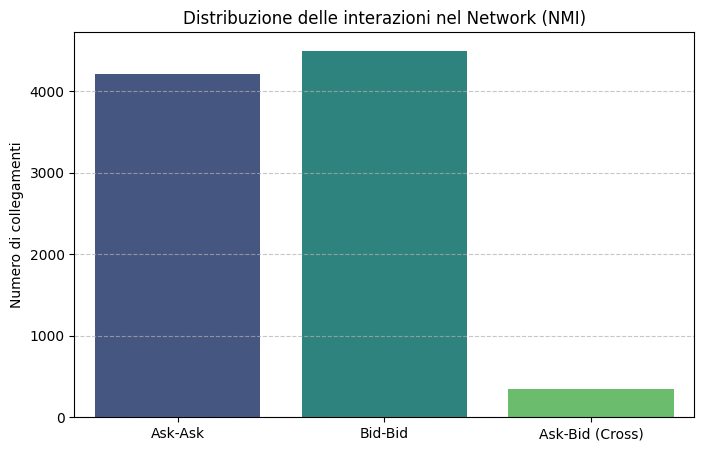

In [18]:
# Assumiamo che il tuo grafo si chiami 'G'
ask_bid_edges = 0
ask_ask_edges = 0
bid_bid_edges = 0

# Iteriamo su tutti i collegamenti (archi) del grafo
for u, v in G.edges():
    # Verifica le tre combinazioni possibili
    if ('ask' in u and 'bid' in v) or ('bid' in u and 'ask' in v):
        ask_bid_edges += 1
    elif 'ask' in u and 'ask' in v:
        ask_ask_edges += 1
    elif 'bid' in u and 'bid' in v:
        bid_bid_edges += 1

print(f"Totale archi nel grafo: {G.number_of_edges()}")
print(f"- Collegamenti Ask-Ask:  {ask_ask_edges}")
print(f"- Collegamenti Bid-Bid:  {bid_bid_edges}")
print(f"- Collegamenti Ask-Bid:  {ask_bid_edges}")

# Visualizzazione della distribuzione
dati_plot = {
    'Ask-Ask': ask_ask_edges, 
    'Bid-Bid': bid_bid_edges, 
    'Ask-Bid (Cross)': ask_bid_edges
}

plt.figure(figsize=(8, 5))
sns.barplot(x=list(dati_plot.keys()), y=list(dati_plot.values()), palette="viridis")
plt.title("Distribuzione delle interazioni nel Network (NMI)")
plt.ylabel("Numero di collegamenti")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Creo visuale grafo

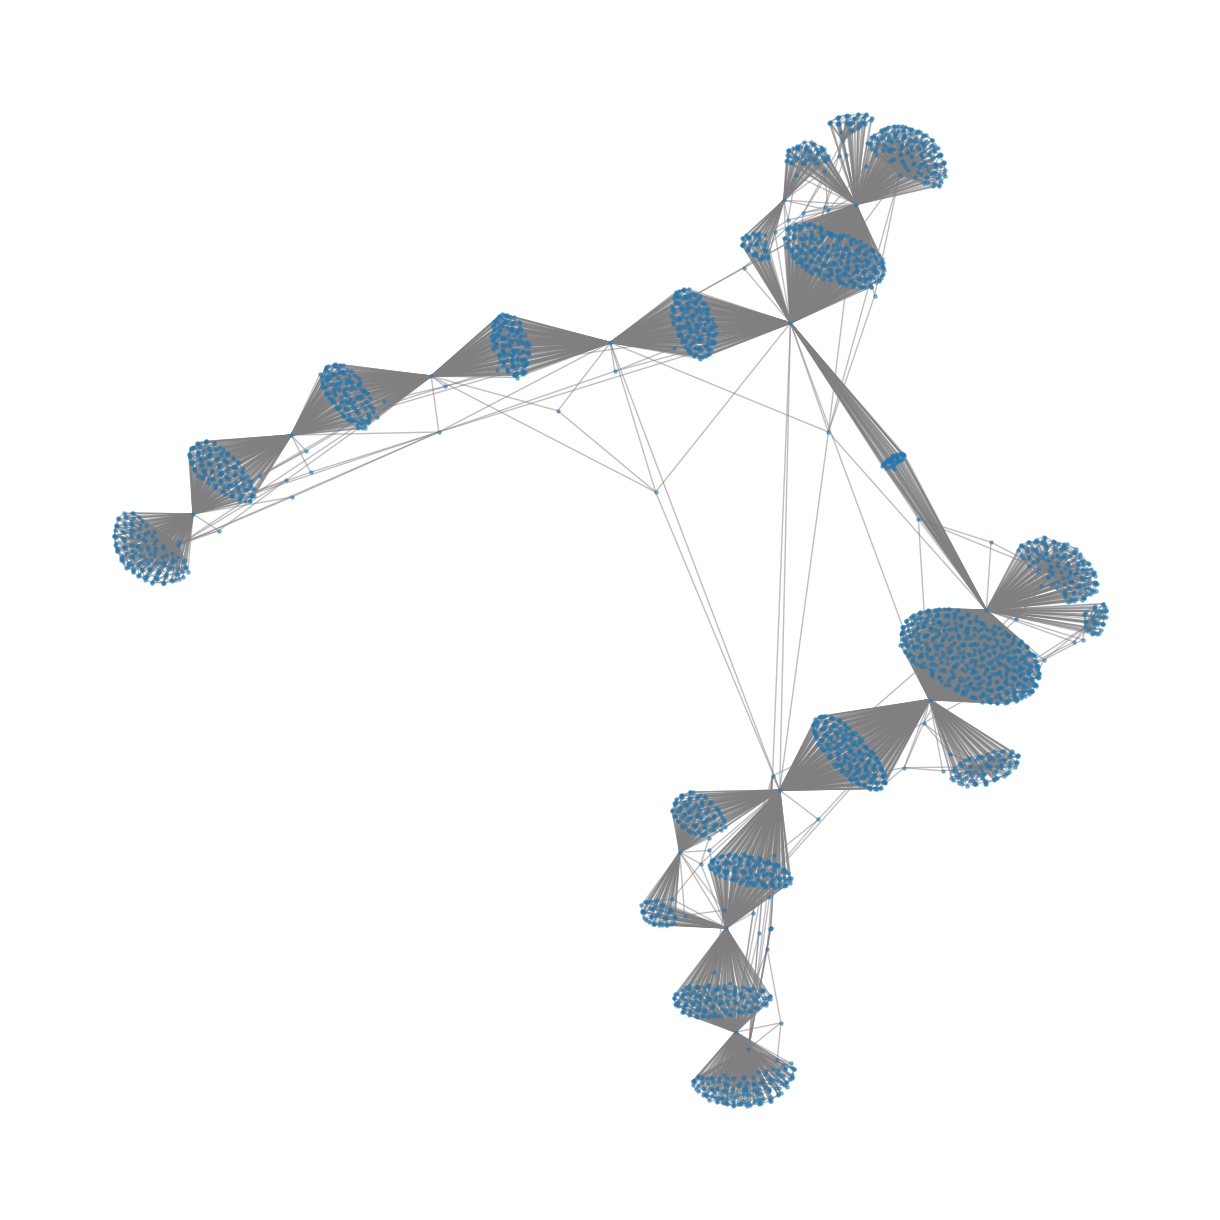

In [16]:
plt.figure(figsize=(12, 12))
nx.draw(G, node_size=5, with_labels=False, edge_color='gray', alpha=0.5)
plt.show()

In [17]:
from pyvis.network import Network
import matplotlib.colors as mcolors
import random


net = Network(height="750px", width="100%", bgcolor="#222222", font_color="white", select_menu=True)

basi = sorted(list(set([n.split('_lag')[0] for n in df_nmi_fixed.columns])))

color_palette = list(mcolors.TABLEAU_COLORS.values()) 
random.shuffle(color_palette)
color_map = {base: color_palette[i % len(color_palette)] for i, base in enumerate(basi)}

for node in G.nodes:
    base_name = node.split('_lag')[0]
    colore = color_map.get(base_name, "#ffffff")
    net.add_node(node, label=node, color=colore, title=f"Variabile: {base_name}")

for edge in G.edges:
    net.add_edge(edge[0], edge[1])

net.set_options("""
{
  "physics": {
    "barnesHut": {
      "gravity": -80000,
      "damping": 0.5
    },
    "minVelocity": 0.75,
    "stabilization": {
      "enabled": true,
      "iterations": 2000
    }
  },
  "interaction": {
    "dragNodes": true,
    "hideEdgesOnDrag": false,
    "hideNodesOnDrag": false
  }
}
""")

net.save_graph("tmfg_colorato.html")